In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from dataclasses import dataclass, field
import ipywidgets as widgets
from IPython.display import display, clear_output

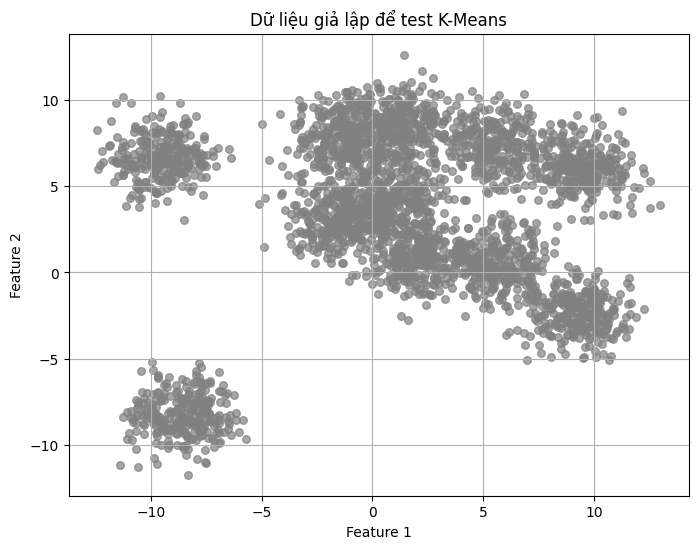

In [2]:
X, y = make_blobs(n_samples=3000, centers=11, cluster_std=1.2, random_state=0)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=30, color='gray', alpha=0.7)
plt.title("Dữ liệu giả lập để test K-Means")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()


In [3]:
@dataclass
class KMeans:
    data: np.ndarray
    k: int
    max_iters: int = 100
    seed: int = np.random.randint(0, 100000)
    centroids: np.ndarray = field(init=False)
    labels: np.ndarray = field(init=False)
    generator: np.random.Generator = field(init=False)
    def __post_init__(self):
        self.generator = np.random.default_rng(self.seed)
        self.labels = np.zeros(self.data.shape[0])
    def _init_algo(self):
        self.centroids = self.data[self.generator.choice(self.data.shape[0], self.k, replace=False)]
    def _assign_labels(self):
        # Sử dụng broadcasting để tính khoảng cách Euclidean từ mỗi điểm đến tất cả các centroids
        distances = np.linalg.norm(self.data[:, np.newaxis] - self.centroids, axis=2)
        # Gán nhãn cho mỗi điểm là index của centroid gần nhất
        self.labels = np.argmin(distances, axis=1)
    def _update_centroids(self):
        new_centroids = np.zeros_like(self.centroids)
        for i in range(self.k):
            # Lấy trung bình cộng của các điểm thuộc cụm i
            points_in_cluster = self.data[self.labels == i]
            if len(points_in_cluster) > 0:
                new_centroids[i] = points_in_cluster.mean(axis=0)
            else:
                # Nếu cụm không có điểm nào, giữ nguyên hoặc reset ngẫu nhiên
                new_centroids[i] = self.centroids[i]
        return new_centroids
    def fit(self):
        self._init_algo()
        for i in range(self.max_iters):
            old_centroids = self.centroids.copy()
            # Bước 1: Gán nhãn
            self._assign_labels()
            # Bước 2: Cập nhật tâm
            self.centroids = self._update_centroids()
            # Bước 3: Kiểm tra hội tụ (nếu tâm không đổi thì dừng sớm)
            if np.allclose(old_centroids, self.centroids):
                print(f"Thuật toán hội tụ tại vòng lặp: {i}")
                break
        return self.labels, self.centroids
    def fit_with_history(self):
        self._init_algo()
        self.history = []
        for i in range(self.max_iters):
            old_centroids = self.centroids.copy()
            self._assign_labels()
            # Lưu lại trạng thái TRƯỚC khi tâm di chuyển
            self.history.append({
                'step': i,
                'centroids': old_centroids.copy(),
                'labels': self.labels.copy()
            })
            self.centroids = self._update_centroids()
            if np.allclose(old_centroids, self.centroids):
                # Lưu thêm trạng thái cuối cùng (khi đã hội tụ)
                self._assign_labels()
                self.history.append({
                    'step': i + 1,
                    'centroids': self.centroids.copy(),
                    'labels': self.labels.copy()
                })
                print(f"Thuật toán hội tụ tại vòng lặp: {i}")
                break
        return self.history

Thuật toán hội tụ tại vòng lặp: 7


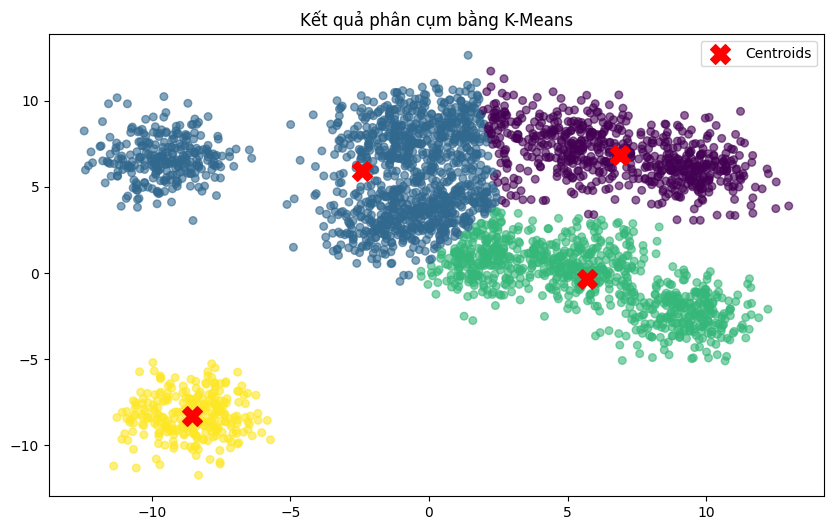

In [4]:
kmeans = KMeans(data=X, k=4)
labels, centers = kmeans.fit()

# Vẽ kết quả
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, s=30, cmap='viridis', alpha=0.6)
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title("Kết quả phân cụm bằng K-Means")
plt.legend()
plt.show()

In [ ]:
model = KMeans(data=X, k=4)
history = model.fit_with_history()

%matplotlib inline 

def plot_step(step):
    state = history[step]
    labels = state['labels']
    centers = state['centroids']
    
    # 2. Dùng subplots để gom đối tượng figure lại dễ quản lý
    fig, ax = plt.subplots(figsize=(8, 6))
    
    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.6, s=30)
    ax.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, edgecolors='black')
    
    if step == len(history) - 1:
        ax.set_title(f"K-Means: ĐÃ HỘI TỤ (Bước {step})", color='green', fontweight='bold')
    else:
        ax.set_title(f"K-Means: Vòng lặp thứ {step}")
        
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    
    plt.show()
    
    # 3. DÒNG QUAN TRỌNG NHẤT: Đóng figure sau khi hiển thị để giải phóng RAM
    plt.close(fig) 

# Tạo thanh trượt
widgets.interact(
    plot_step, 
    step=widgets.IntSlider(
        min=0, 
        max=len(history)-1, 
        step=1, 
        value=0, 
        description='Vòng lặp:'
    )
);

Thuật toán hội tụ tại vòng lặp: 7


interactive(children=(IntSlider(value=0, description='Vòng lặp:', max=8), Output()), _dom_classes=('widget-int…